In [22]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from PyEMD import CEEMDAN
from scipy.signal import hilbert
from sklearn.decomposition import FastICA
from scipy.stats import pearsonr
import pickle

# Konfigurasi Path yang BENAR (Mundur 3 tingkat dari 'training' ke root)
PROJECT_ROOT = os.path.abspath('../../../') 

# Atau jika Anda ingin menggunakan Absolute Path (Buka komentar baris di bawah jika masih error):
# PROJECT_ROOT = r'd:\GitRepos\EEG-to-Text_Conformer-Transducer'

RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'dataset/raw')
TRAIN_CSV = os.path.join(PROJECT_ROOT, 'dataset/SUB4_eq_3_0_train.csv')

# Memasukkan folder src/model agar python bisa menemukan CharTokenizer
model_path = os.path.join(PROJECT_ROOT, 'src', 'model')
sys.path.insert(0, model_path)

from misc.tokenizer import CharTokenizer
print("✅ Berhasil import CharTokenizer!")

EEG_CHANNELS = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 
                'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 
                'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4']

CONFIG = {
    'sample_rate': 256, 'hop_length': 8, 'win_length': 16,
    'f_min': 0.2, 'f_max': 45.0, 'ica_threshold': 0.8,
    'start_imf': 2, 'ceemdan_trials': 15, 'n_freq_bins': 65,
}

# 1. Load Data 1 Baris Pertama saja dari data training
df_train = pd.read_csv(TRAIN_CSV)
sample_row = df_train.iloc[0]

id_val = str(sample_row['id'])
subject = sample_row['subject']
gender = sample_row['gender']
ground_truth_sentence = sample_row['sentence']

# Load sinyal mentah
csv_folder = os.path.join(RAW_DATA_PATH, gender, subject, 'csv')
matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]
file_path = os.path.join(csv_folder, matching_files[0])

df_eeg = pd.read_csv(file_path, skiprows=1)
raw_eeg_signal = df_eeg[EEG_CHANNELS].values

print("-" * 40)
print(f"Subjek        : {subject}")
print(f"Kalimat Target: {ground_truth_sentence}")
print(f"Shape Matriks : {raw_eeg_signal.shape} (Time x Channels)")
print("✅ Setup Data Berhasil! Lanjut ke Cell berikutnya.")

✅ Berhasil import CharTokenizer!
----------------------------------------
Subjek        : SUB4
Kalimat Target: hasilnya sedikit mengejutkan
Shape Matriks : (555, 14) (Time x Channels)
✅ Setup Data Berhasil! Lanjut ke Cell berikutnya.


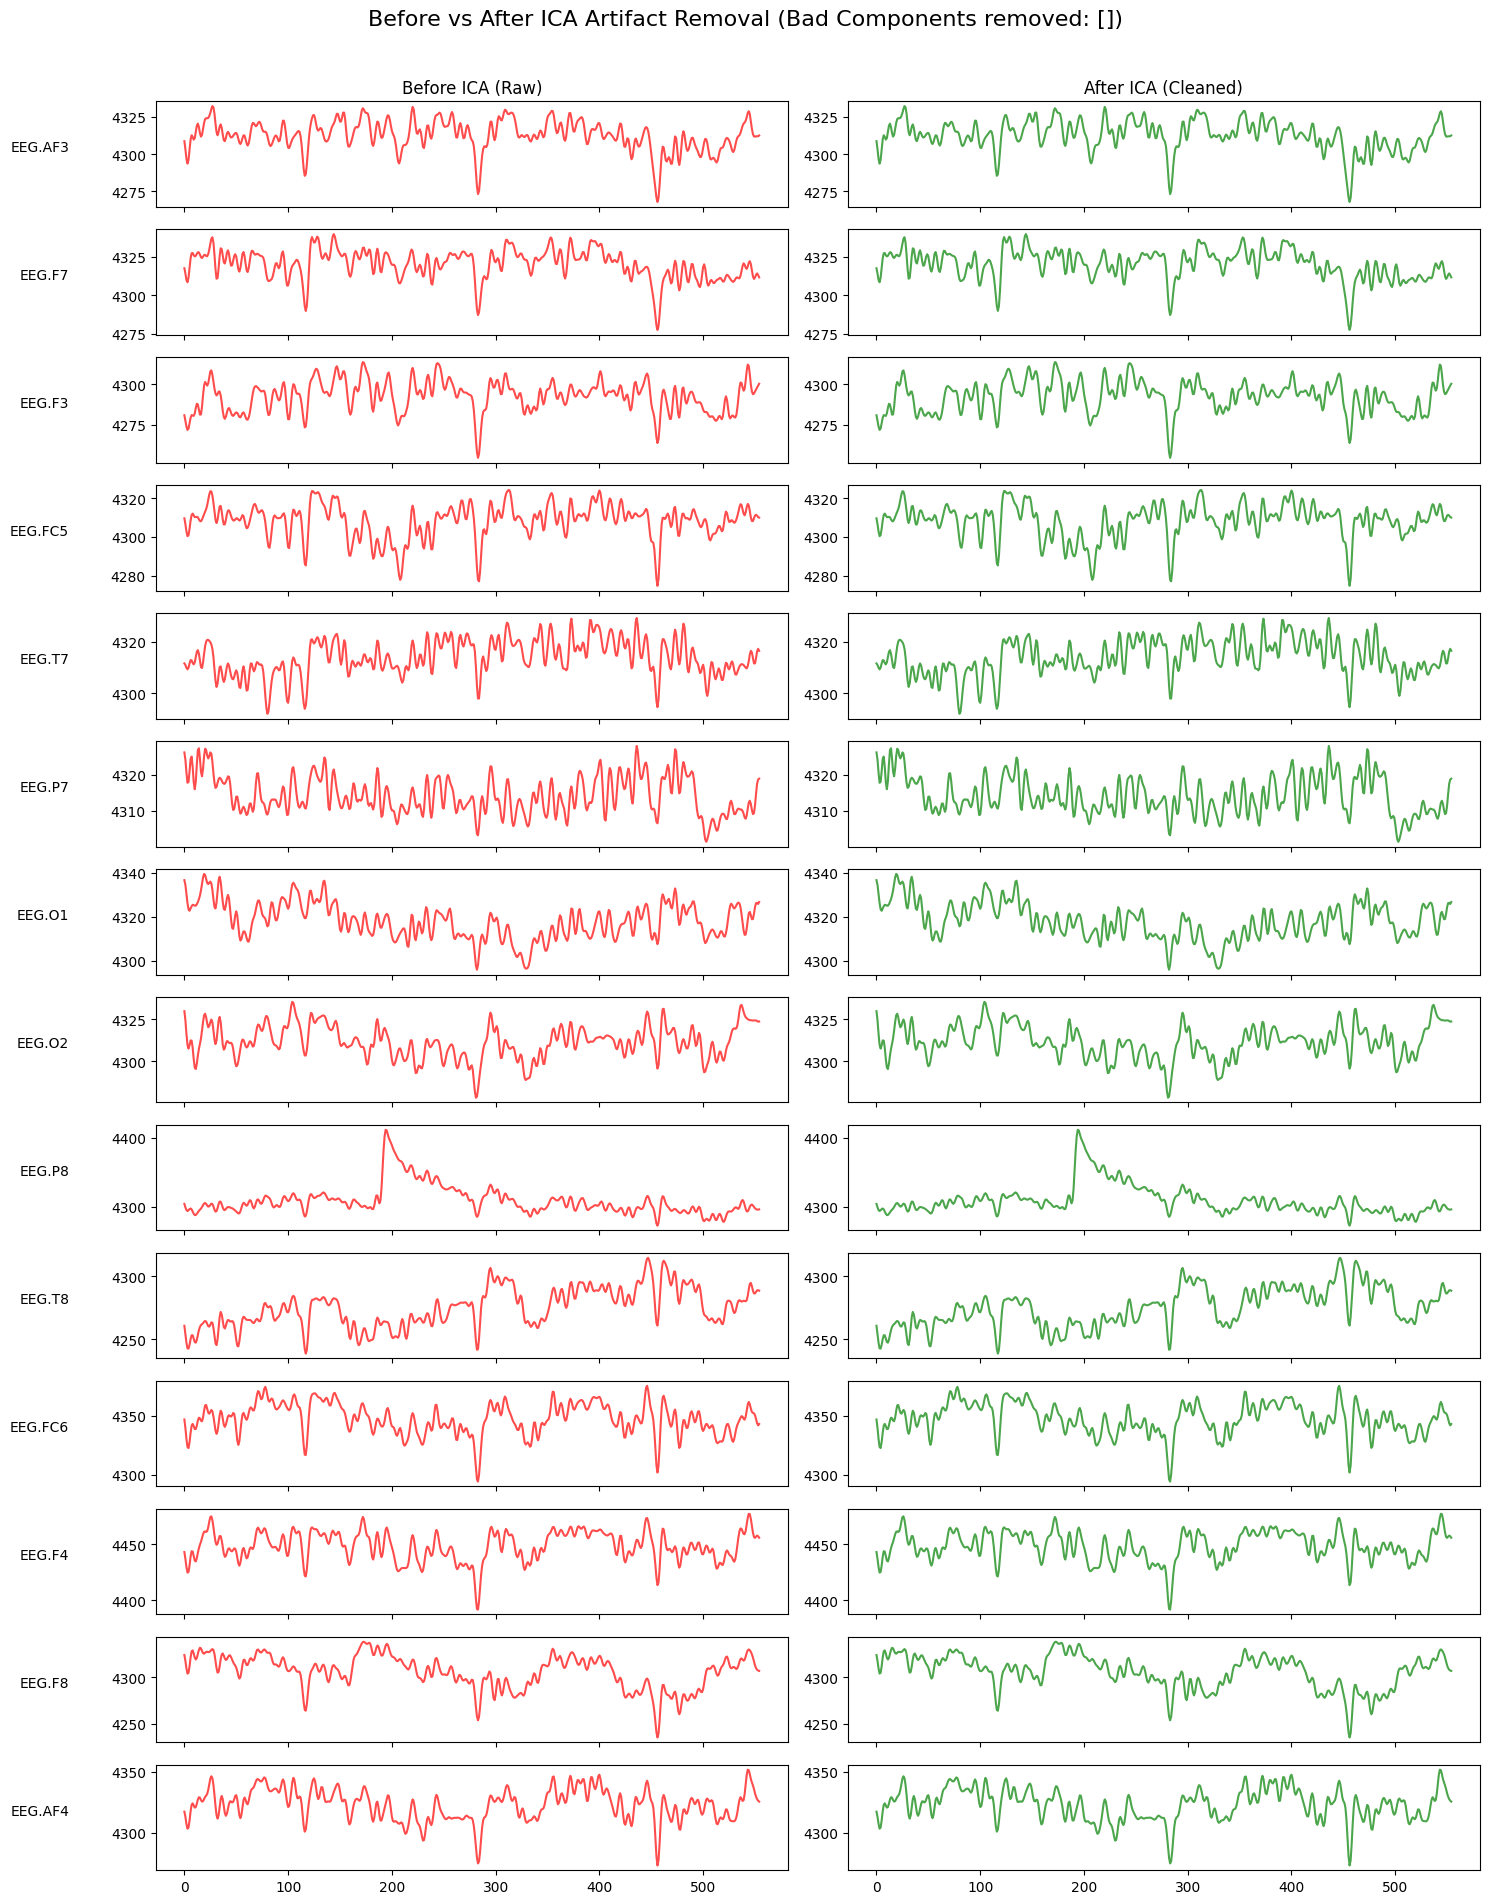

In [ ]:
def remove_ocular_artifacts_ica_demo(eeg_signal, ch_names, threshold=0.6):
    frontal_indices = [i for i, ch in enumerate(ch_names) if 'AF3' in ch or 'AF4' in ch]
    ica = FastICA(n_components=eeg_signal.shape[1], random_state=42, max_iter=1000, tol=0.01)
    components = ica.fit_transform(eeg_signal) 

    bad_components = []
    for i in range(components.shape[1]):
        is_artifact = False
        for f_idx in frontal_indices:
            corr, _ = pearsonr(components[:, i], eeg_signal[:, f_idx])
            if abs(corr) > threshold:
                is_artifact = True
                break
        if is_artifact: bad_components.append(i)

    components_cleaned = components.copy()
    if bad_components:
        components_cleaned[:, bad_components] = 0.0

    cleaned_signal = ica.inverse_transform(components_cleaned)
    return cleaned_signal, bad_components

cleaned_eeg_signal, bad_comps = remove_ocular_artifacts_ica_demo(raw_eeg_signal, EEG_CHANNELS, CONFIG['ica_threshold'])

# Plotting Before & After
fig, axes = plt.subplots(14, 2, figsize=(15, 20), sharex=True)
fig.suptitle(f"Before vs After ICA Artifact Removal (Bad Components removed: {bad_comps})", fontsize=16)

for i in range(14):
    axes[i, 0].plot(raw_eeg_signal[:, i], color='red', alpha=0.7)
    axes[i, 0].set_ylabel(EEG_CHANNELS[i], rotation=0, labelpad=30, ha='right')
    axes[i, 1].plot(cleaned_eeg_signal[:, i], color='green', alpha=0.7)
    
    if i == 0:
        axes[i, 0].set_title("Before ICA (Raw)")
        axes[i, 1].set_title("After ICA (Cleaned)")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Mengeksekusi CEEMDAN untuk channel EEG.AF3...


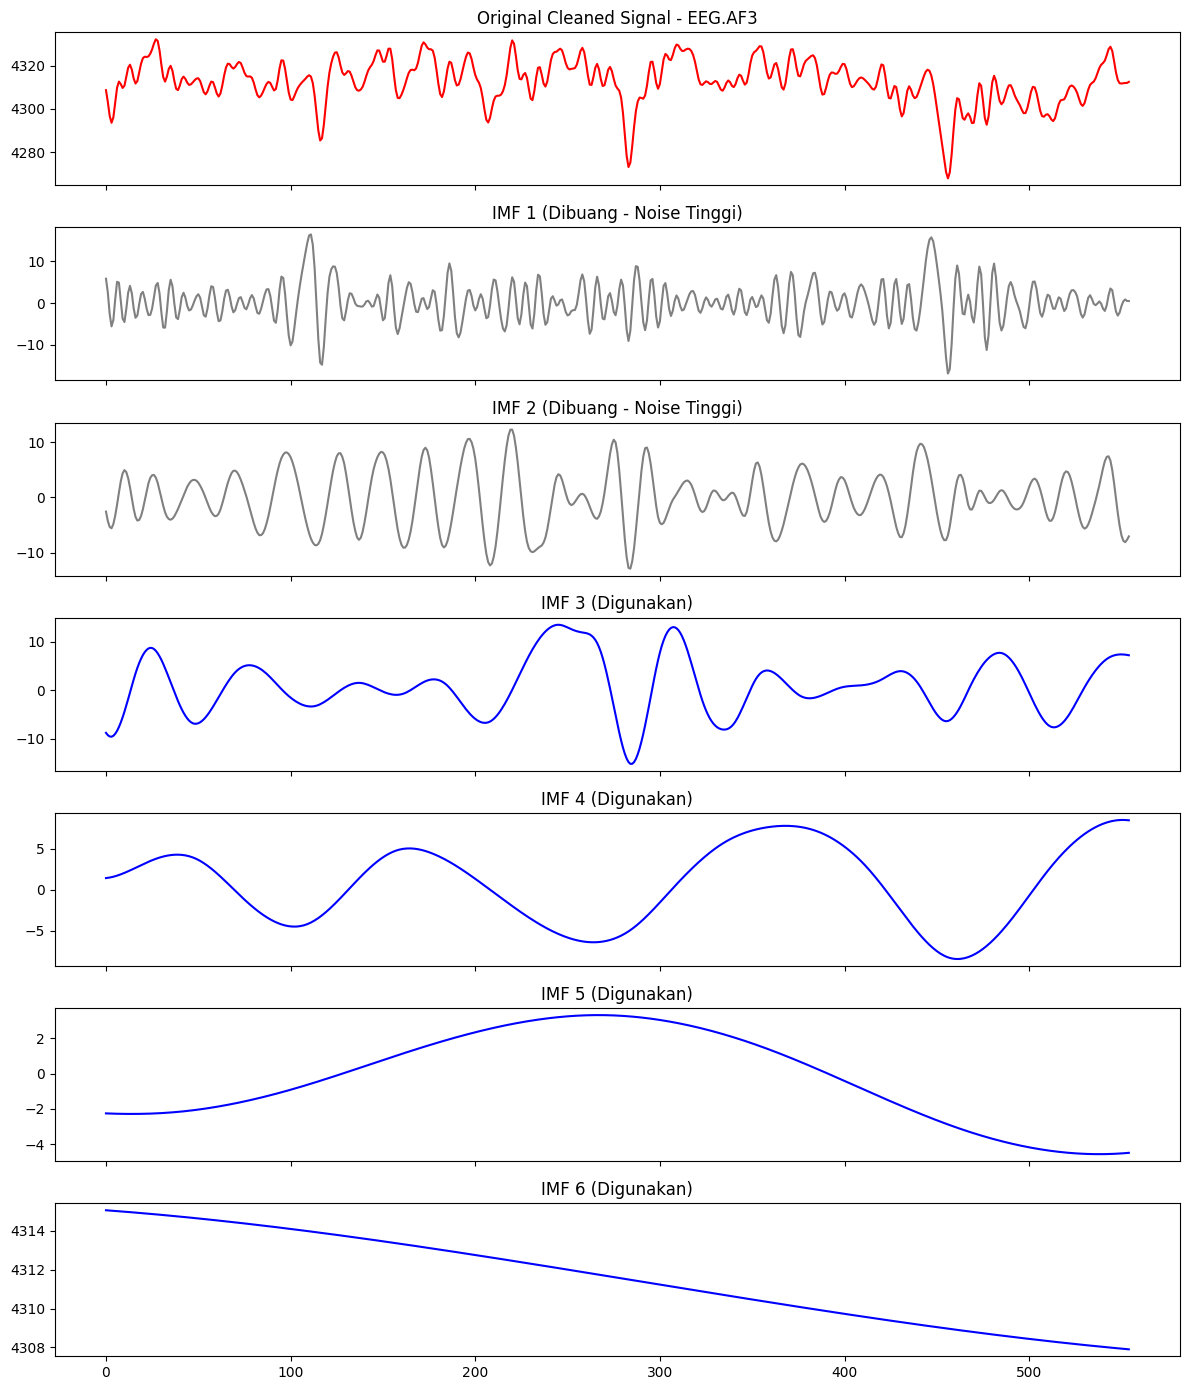

In [24]:
ch_idx = 0 # Ambil channel AF3
single_channel_signal = cleaned_eeg_signal[:, ch_idx].astype(np.float64)

print(f"Mengeksekusi CEEMDAN untuk channel {EEG_CHANNELS[ch_idx]}...")
ceemdan = CEEMDAN(trials=CONFIG['ceemdan_trials'], noise_scale=0.2, parallel=False)
imfs = ceemdan(single_channel_signal)

num_imfs = imfs.shape[0]

fig, axes = plt.subplots(num_imfs + 1, 1, figsize=(12, 2 * (num_imfs + 1)), sharex=True)
axes[0].plot(single_channel_signal, 'r')
axes[0].set_title(f"Original Cleaned Signal - {EEG_CHANNELS[ch_idx]}")

for i in range(num_imfs):
    # Highlight IMF yang dibuang (start_imf = 2, berarti IMF 0 dan 1 dibuang)
    color = 'blue' if i >= CONFIG['start_imf'] else 'gray'
    axes[i+1].plot(imfs[i], color=color)
    axes[i+1].set_title(f"IMF {i+1} {'(Digunakan)' if i >= CONFIG['start_imf'] else '(Dibuang - Noise Tinggi)'}")

plt.tight_layout()
plt.show()

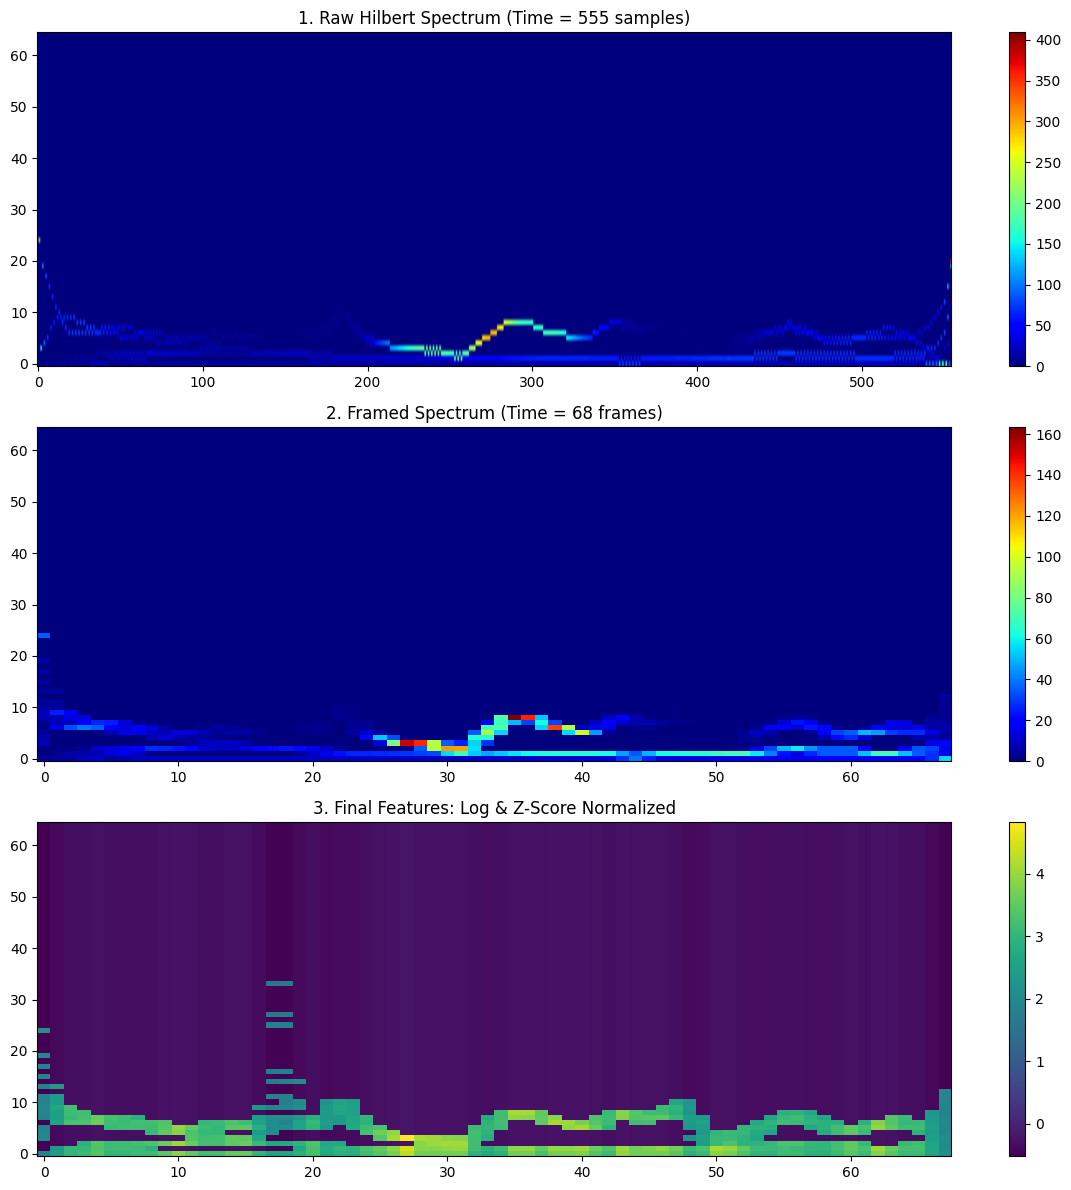

In [25]:
# Kita buat versi step-by-step dari fungsi komputasi Hilbert
fs = CONFIG['sample_rate']
freq_edges = np.linspace(CONFIG['f_min'], CONFIG['f_max'], CONFIG['n_freq_bins'] + 1)
n_samples = single_channel_signal.shape[0]

# 1. Menghitung Hilbert Transform dari IMF yang valid (Mulai dari IMF ke-2)
valid_imfs = imfs[CONFIG['start_imf']:]
hilbert_spec_raw = np.zeros((CONFIG['n_freq_bins'], n_samples))

for i in range(valid_imfs.shape[0]):
    analytic_signal = hilbert(valid_imfs[i])
    amp = np.abs(analytic_signal)
    phase = np.unwrap(np.angle(analytic_signal))
    freq = (np.diff(phase) / (2.0*np.pi) * fs)
    freq = np.insert(freq, 0, freq[0])
    
    bin_indices = np.digitize(freq, freq_edges) - 1
    for t in range(n_samples):
        b = bin_indices[t]
        if 0 <= b < CONFIG['n_freq_bins']:
            hilbert_spec_raw[b, t] += (amp[t] ** 2)

# 2. Framing (Memotong menjadi jendela waktu sesuai hop_length)
win_length = CONFIG['win_length']
hop_length = CONFIG['hop_length']
n_frames = 1 + (n_samples - win_length) // hop_length
framed_spec = np.zeros((CONFIG['n_freq_bins'], n_frames))

for t_idx in range(n_frames):
    start = t_idx * hop_length
    end = start + win_length
    framed_spec[:, t_idx] = np.mean(hilbert_spec_raw[:, start:end], axis=1)

# 3. Log & Z-Score Normalization (Mirip dengan compute_hilbert_spectrum asli)
# Di fungsi asli Anda, ini dilakukan SETELAH semua channel digabung. 
# Di sini kita simulasikan untuk 1 channel.
log_spec = np.log(framed_spec + 1e-9)
mean_val = np.mean(log_spec, axis=0)
std_val = np.std(log_spec, axis=0)
norm_spec = (log_spec - mean_val) / (std_val + 1e-6)

# PLOTTING TAHAPAN
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Raw Hilbert Spectrum (Sumbu waktu asli)
im1 = axes[0].imshow(hilbert_spec_raw, aspect='auto', origin='lower', cmap='jet')
axes[0].set_title(f"1. Raw Hilbert Spectrum (Time = {n_samples} samples)")
fig.colorbar(im1, ax=axes[0])

# Plot 2: Framed Spectrum (Setelah di-windowing)
im2 = axes[1].imshow(framed_spec, aspect='auto', origin='lower', cmap='jet')
axes[1].set_title(f"2. Framed Spectrum (Time = {n_frames} frames)")
fig.colorbar(im2, ax=axes[1])

# Plot 3: Log & Z-Score Normalized (Siap masuk Neural Network)
im3 = axes[2].imshow(norm_spec, aspect='auto', origin='lower', cmap='viridis')
axes[2].set_title(f"3. Final Features: Log & Z-Score Normalized")
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [26]:
# Membuat / Memuat Tokenizer persis seperti di skrip
all_texts = df_train['sentence'].tolist() # Gunakan teks train sebagai corpus
tokenizer = CharTokenizer(transcripts=all_texts)

# Demonstrasi Tokenisasi
raw_text = ground_truth_sentence
int_tokens = tokenizer.text_to_int(raw_text)

print(f"1. Teks Asli       : '{raw_text}'")
print(f"2. Integer Tokens  : {int_tokens}")
print(f"3. Jumlah Karakter : {len(raw_text)}")
print(f"4. Jumlah Token    : {len(int_tokens)}")

# Tampilkan pemetaan huruf ke integer menggunakan int_to_text()
# Kita bungkus [i] ke dalam list karena fungsi ini mengekspektasikan array/list
decoded_chars = [tokenizer.int_to_text([i]) for i in int_tokens]
print(f"5. Pemetaan Balik  : {decoded_chars}")

# Memastikan hasil gabungan sama dengan aslinya
reconstructed_text = tokenizer.int_to_text(int_tokens)
print(f"6. Teks Gabungan   : '{reconstructed_text}'")

# Representasi Tensor untuk Model
tensor_target = torch.LongTensor(int_tokens)
print(f"\nTensor PyTorch:\n{tensor_target}")

1. Teks Asli       : 'hasilnya sedikit mengejutkan'
2. Integer Tokens  : [9, 2, 19, 10, 13, 15, 24, 2, 1, 19, 6, 5, 10, 12, 10, 20, 1, 14, 6, 15, 8, 6, 11, 21, 20, 12, 2, 15]
3. Jumlah Karakter : 28
4. Jumlah Token    : 28
5. Pemetaan Balik  : ['h', 'a', 's', 'i', 'l', 'n', 'y', 'a', ' ', 's', 'e', 'd', 'i', 'k', 'i', 't', ' ', 'm', 'e', 'n', 'g', 'e', 'j', 'u', 't', 'k', 'a', 'n']
6. Teks Gabungan   : 'hasilnya sedikit mengejutkan'

Tensor PyTorch:
tensor([ 9,  2, 19, 10, 13, 15, 24,  2,  1, 19,  6,  5, 10, 12, 10, 20,  1, 14,
         6, 15,  8,  6, 11, 21, 20, 12,  2, 15])


In [27]:
import time
from IPython.display import clear_output
import seaborn as sns
import torch
import numpy as np

from PyEMD import CEEMDAN
from scipy.signal import hilbert

# 1. Definisi Variabel Global & Path
SUBJECT = 'SUB4'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'src/pipelines/training')
# Menggunakan akhiran 6_1.pt sesuai skrip Anda
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f'{SUBJECT}_eq_3_0_fixed_hilbert_best_model_6_1.pt')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Import Arsitektur Model
from model import ConformerTransducer

# 2. Fungsi Komputasi Hilbert Penuh (14 Channel)
def compute_hilbert_spectrum_full(eeg_signal, config):
    n_samples, n_channels = eeg_signal.shape
    fs, f_min, f_max, n_bins = config['sample_rate'], config['f_min'], config['f_max'], config['n_freq_bins']
    hop_length, win_length = config['hop_length'], config['win_length']
    start_imf = config.get('start_imf', 2)
    freq_edges = np.linspace(f_min, f_max, n_bins + 1)
    
    ceemdan = CEEMDAN(trials=config['ceemdan_trials'], noise_scale=0.2, parallel=False)
    all_channel_spectra = []
    
    for ch_idx in range(n_channels):
        signal = eeg_signal[:, ch_idx].astype(np.float64)
        imfs = ceemdan(signal)
        imfs = imfs[start_imf:] if start_imf < imfs.shape[0] else imfs[-1:]
        
        hilbert_spec = np.zeros((n_bins, n_samples))
        for i in range(imfs.shape[0]):
            analytic_signal = hilbert(imfs[i])
            amp, phase = np.abs(analytic_signal), np.unwrap(np.angle(analytic_signal))
            freq = (np.diff(phase) / (2.0*np.pi) * fs)
            freq = np.insert(freq, 0, freq[0])
            bin_indices = np.digitize(freq, freq_edges) - 1
            for t in range(n_samples):
                b = bin_indices[t]
                if 0 <= b < n_bins: hilbert_spec[b, t] += (amp[t] ** 2) 
        
        current_n_samples = n_samples
        if current_n_samples > win_length:
            remainder = (current_n_samples - win_length) % hop_length
            if remainder > 0:
                pad_length = hop_length - remainder
                hilbert_spec = np.pad(hilbert_spec, ((0, 0), (0, pad_length)), mode='constant')
                current_n_samples += pad_length

        if current_n_samples < win_length:
            framed_spec = np.zeros((n_bins, 0)) 
        else:
            n_frames = 1 + (current_n_samples - win_length) // hop_length
            framed_spec = np.zeros((n_bins, n_frames))
            for t_idx in range(n_frames):
                start = t_idx * hop_length
                end = start + win_length  
                framed_spec[:, t_idx] = np.mean(hilbert_spec[:, start:end], axis=1)  
        all_channel_spectra.append(framed_spec)
        
    all_channel_spectra = np.array(all_channel_spectra)
    features_transposed = all_channel_spectra.transpose(2, 0, 1)
    features_flat = features_transposed.reshape(features_transposed.shape[0], -1)
    features_flat = np.log(features_flat + 1e-9)
    mean_val, std_val = np.mean(features_flat, axis=0), np.std(features_flat, axis=0)
    features_flat = (features_flat - mean_val) / (std_val + 1e-6)
    
    return features_flat.astype(np.float32)

print("Mengekstraksi fitur Hilbert Spectrum untuk 14 channel (Mohon tunggu sebentar)...")
# Menggunakan cleaned_eeg_signal yang sudah bersih dari Cell 2
final_features = compute_hilbert_spectrum_full(cleaned_eeg_signal, CONFIG)

# 3. Format ke Tensor PyTorch
features = torch.FloatTensor(final_features).unsqueeze(0).to(DEVICE)
feature_length = torch.LongTensor([final_features.shape[0]]).to(DEVICE)
targets = tensor_target.unsqueeze(0).to(DEVICE) # Variabel ini didapat dari Cell 5

# =======================================================
# TAMBAHAN PENTING: Menyuntikkan dimensi model ke CONFIG
# =======================================================
CONFIG['input_dim'] = 14 * 65
CONFIG['encoder_dim'] = 128
CONFIG['decoder_dim'] = 128
CONFIG['joint_dim'] = 128
CONFIG['vocab_size'] = tokenizer.vocab_size() # Didapat dari objek tokenizer di Cell 5

# 4. Load Model
print(f"\nMemuat model dari {os.path.basename(BEST_MODEL_PATH)}...")
model = ConformerTransducer(CONFIG).to(DEVICE)

try:
    saved_data = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(saved_data['model_state_dict'], strict=False)
    model.eval()
    print("✅ Model berhasil dimuat!")
except FileNotFoundError:
    print(f"❌ ERROR: File model tidak ditemukan di {BEST_MODEL_PATH}")
    print("Pastikan Anda sudah menyelesaikan proses training sebelumnya.")

print("-" * 50)
print(f"Subjek       : {SUBJECT}")
print(f"Target Asli  : {ground_truth_sentence}")
print(f"Shape Matriks: {features.shape} (Batch, Frames, Fitur)")

Mengekstraksi fitur Hilbert Spectrum untuk 14 channel (Mohon tunggu sebentar)...

Memuat model dari SUB4_eq_3_0_fixed_hilbert_best_model_6_1.pt...
✅ Model berhasil dimuat!
--------------------------------------------------
Subjek       : SUB4
Target Asli  : hasilnya sedikit mengejutkan
Shape Matriks: torch.Size([1, 69, 910]) (Batch, Frames, Fitur)


Memulai proses decoding RNN-T (Beam Search k=3)...

--------------------------------------------------
[Frame 017/18] Prediksi: apakah anda bisa sedang saja mengant saja
--------------------------------------------------
Hasil Akhir  : apakah anda bisa sedang saja mengant saja
Ground Truth : hasilnya sedikit mengejutkan
Mengintip 3 Semesta Teratas secara Autoregressive (Beam Search k=3):
Step 01 (T=000) | Semesta 1: 'p' (-1.2)  |  Semesta 2: 'a' (-1.4)  |  Semesta 3: 's' (-1.8)  |  
Step 02 (T=000) | Semesta 1: 'ap' (-1.7)  |  Semesta 2: 'sa' (-1.9)  |  Semesta 3: 'pe' (-2.0)  |  
Step 03 (T=000) | Semesta 1: 'apa' (-1.7)  |  Semesta 2: 'say' (-2.1)  |  Semesta 3: 'per' (-3.3)  |  
Step 04 (T=000) | Semesta 1: 'saya' (-2.1)  |  Semesta 2: 'apa' (-2.3)  |  Semesta 3: 'apak' (-2.6)  |  
Step 05 (T=000) | Semesta 1: 'apaka' (-2.7)  |  Semesta 2: 'saya ' (-2.7)  |  Semesta 3: 'apa' (-2.8)  |  
Step 06 (T=000) | Semesta 1: 'apaka' (-3.4)  |  Semesta 2: 'apa' (-3.4)  |  Semesta 3: 'apakah' (

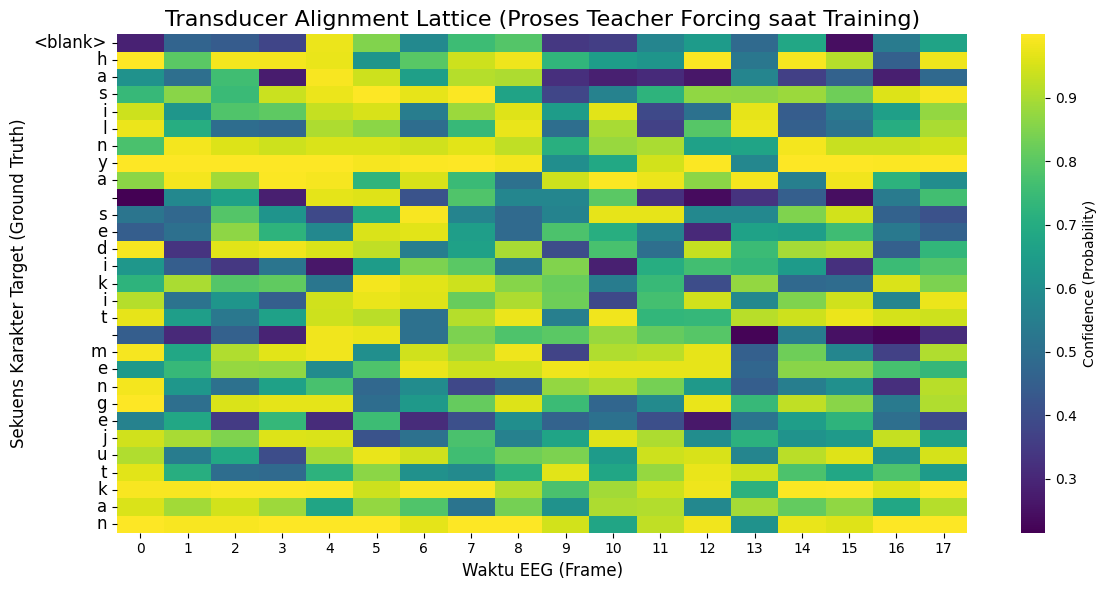

In [42]:
import time
import torch
import torch.nn.functional as F

def live_beam_decode_demo(model, features, tokenizer, beam_size=3, max_sym_per_frame=15, delay=0.1):
    """Mendemonstrasikan inferensi RNN-Transducer (Beam Search) secara live"""
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        # Inisialisasi: (score, char_sequence, hidden_state, decoder_input)
        init_dec_in = torch.tensor([[0]], dtype=torch.long, device=DEVICE)
        init_hidden = model.decoder.init_hidden(1, DEVICE)
        beam = [(0.0, [], init_hidden, init_dec_in)]
        
        t = 0
        print(f"Memulai proses decoding RNN-T (Beam Search k={beam_size})...\n")
        print("-" * 50)
        
        while t < encoder_out.size(1):
            current_enc_frame = encoder_out[:, t:t+1, :]
            
            for sym_count in range(max_sym_per_frame):
                new_beam = []
                
                for log_p, char_seq, hidden_state, dec_input in beam:
                    decoder_out, next_hidden_state = model.decoder(dec_input, hidden_state)
                    
                    enc_proj = model.joiner.encoder_proj(current_enc_frame)
                    dec_proj = model.joiner.decoder_proj(decoder_out)
                    joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
                    joint = model.joiner.activation(joint)
                    logits = model.joiner.output_proj(joint)
                    
                    log_probs = F.log_softmax(logits, dim=-1)[0, 0, 0, :]
                    top_k_log_probs, top_k_indices = torch.topk(log_probs, beam_size)
                    
                    for i in range(beam_size):
                        idx = top_k_indices[i].item()
                        new_log_p = log_p + top_k_log_probs[i].item()
                        
                        if idx == 0:
                            # Jika <blank>, rute ini berhenti di frame ini (tanda True)
                            new_beam.append((new_log_p, char_seq, hidden_state, dec_input, True))
                        else:
                            # Jika huruf, rute ini berlanjut (tanda False)
                            char = tokenizer.int_to_text([idx])[0]
                            new_dec_input = torch.tensor([[idx]], dtype=torch.long, device=DEVICE)
                            new_beam.append((new_log_p, char_seq + [char], next_hidden_state, new_dec_input, False))
                
                # Sortir dan ambil top-k semesta
                new_beam.sort(key=lambda x: x[0], reverse=True)
                beam = [(b[0], b[1], b[2], b[3]) for b in new_beam[:beam_size]]
                
                # --- FORMAT KELUARAN LIVE (Mencetak Semesta Peringkat 1) ---
                current_best_sentence = "".join(beam[0][1])
                # Menambahkan spasi kosong di belakang untuk menimpa teks sebelumnya jika kalimatnya memendek (revisi)
                print(f"\r[Frame {t:03d}/{encoder_out.size(1)}] Prediksi: {current_best_sentence.ljust(40)}", end="")
                time.sleep(delay)
                # -----------------------------------------------------------
                
                # Cek apakah seluruh top-k memprediksi <blank>
                if all([b[4] for b in new_beam[:beam_size] if len(b) > 4]):
                    break 
                    
            t += 1
            
        print("\n" + "-" * 50)
        print(f"Hasil Akhir  : {''.join(beam[0][1])}")
        print(f"Ground Truth : {ground_truth_sentence}")

live_beam_decode_demo(model, features, tokenizer, beam_size=3, delay=0.05)

def inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=10):
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        init_dec_in = torch.tensor([[0]], dtype=torch.long, device=DEVICE)
        init_hidden = model.decoder.init_hidden(1, DEVICE)
        beam = [(0.0, [], init_hidden, init_dec_in)]
        
        print(f"Mengintip 3 Semesta Teratas secara Autoregressive (Beam Search k={beam_size}):")
        print("="*80)
        
        t = 0
        step = 1
        
        while t < encoder_out.size(1) and step <= inspect_steps:
            current_enc_frame = encoder_out[:, t:t+1, :]
            
            for sym_count in range(15):
                new_beam = []
                for log_p, char_seq, hidden_state, dec_input in beam:
                    decoder_out, next_hidden_state = model.decoder(dec_input, hidden_state)
                    
                    enc_proj = model.joiner.encoder_proj(current_enc_frame)
                    dec_proj = model.joiner.decoder_proj(decoder_out)
                    joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
                    joint = model.joiner.activation(joint)
                    logits = model.joiner.output_proj(joint)
                    
                    log_probs = F.log_softmax(logits, dim=-1)[0, 0, 0, :]
                    top_k_log_probs, top_k_indices = torch.topk(log_probs, beam_size)
                    
                    for i in range(beam_size):
                        idx = top_k_indices[i].item()
                        new_log_p = log_p + top_k_log_probs[i].item()
                        
                        if idx == 0:
                            new_beam.append((new_log_p, char_seq, hidden_state, dec_input, True))
                        else:
                            char = tokenizer.int_to_text([idx])[0]
                            new_dec_input = torch.tensor([[idx]], dtype=torch.long, device=DEVICE)
                            new_beam.append((new_log_p, char_seq + [char], next_hidden_state, new_dec_input, False))
                
                new_beam.sort(key=lambda x: x[0], reverse=True)
                beam = [(b[0], b[1], b[2], b[3]) for b in new_beam[:beam_size]]
                
                # --- FORMAT KELUARAN INSPEKSI ---
                print(f"Step {step:02d} (T={t:03d}) |", end=" ")
                for i in range(min(beam_size, len(beam))):
                    score = beam[i][0]
                    teks = "".join(beam[i][1]) if len(beam[i][1]) > 0 else "<blank>"
                    print(f"Semesta {i+1}: '{teks}' ({score:.1f})", end="  |  ")
                print("")
                # --------------------------------
                
                step += 1
                if step > inspect_steps: break
                
                if all([b[4] for b in new_beam[:beam_size] if len(b) > 4]):
                    break 
            t += 1

inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=15)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_joiner_training_alignment(model, features, targets, tokenizer):
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        # Teacher Forcing (Khas Proses Training)
        batch_size = targets.shape[0]
        blank_col = torch.zeros((batch_size, 1), dtype=torch.long, device=DEVICE)
        decoder_input = torch.cat([blank_col, targets], dim=1)
        hidden_state = model.decoder.init_hidden(batch_size, DEVICE)
        
        decoder_out, _ = model.decoder(decoder_input, hidden_state)
        
        enc_proj = model.joiner.encoder_proj(encoder_out)
        dec_proj = model.joiner.decoder_proj(decoder_out)
        joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
        joint = model.joiner.activation(joint)
        logits = model.joiner.output_proj(joint)
        
        probs = torch.nn.functional.softmax(logits, dim=-1)
        max_probs = probs.max(dim=-1).values[0].cpu().numpy()
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(max_probs.T, cmap='viridis', cbar_kws={'label': 'Confidence (Probability)'})
        
        target_chars = ['<blank>'] + [tokenizer.int_to_text([i.item()])[0] for i in targets[0]]
        plt.yticks(ticks=np.arange(len(target_chars)) + 0.5, labels=target_chars, rotation=0, fontsize=12)
        
        plt.title("Transducer Alignment Lattice (Proses Teacher Forcing saat Training)", fontsize=16)
        plt.xlabel("Waktu EEG (Frame)", fontsize=12)
        plt.ylabel("Sekuens Karakter Target (Ground Truth)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

plot_joiner_training_alignment(model, features, targets, tokenizer)

Memulai proses decoding RNN-T (Sesuai cara kerja asli)...

--------------------------------------------------
[Frame 018/18] Prediksi: perpai mengantu
--------------------------------------------------
Hasil Akhir  : perpai mengantu
Ground Truth : hasilnya sedikit mengejutkan
Mengintip 3 tebakan teratas secara Autoregressive (Sesuai Inferensi Asli):
Step 01 (T=000) | #1: 'p' (28.7%)  |  #2: 'a' (23.7%)  |  #3: 's' (16.1%)  |   --> Terpilih: 'p'
Step 02 (T=000) | #1: 'e' (45.6%)  |  #2: 'a' (44.4%)  |  #3: 'u' (5.8%)  |   --> Terpilih: 'e'
Step 03 (T=000) | #1: 'r' (29.2%)  |  #2: 'n' (25.0%)  |  #3: 'm' (15.9%)  |   --> Terpilih: 'r'
Step 04 (T=000) | #1: 'p' (29.6%)  |  #2: '<blank>' (22.9%)  |  #3: 't' (13.0%)  |   --> Terpilih: 'p'
Step 05 (T=000) | #1: 'a' (42.9%)  |  #2: 'i' (33.3%)  |  #3: 'u' (19.8%)  |   --> Terpilih: 'a'
Step 06 (T=000) | #1: '<blank>' (90.6%)  |  #2: 't' (4.5%)  |  #3: 'k' (1.9%)  |   --> Terpilih: '<blank>'
Step 07 (T=001) | #1: 'i' (60.7%)  |  #2: 't' (16.4

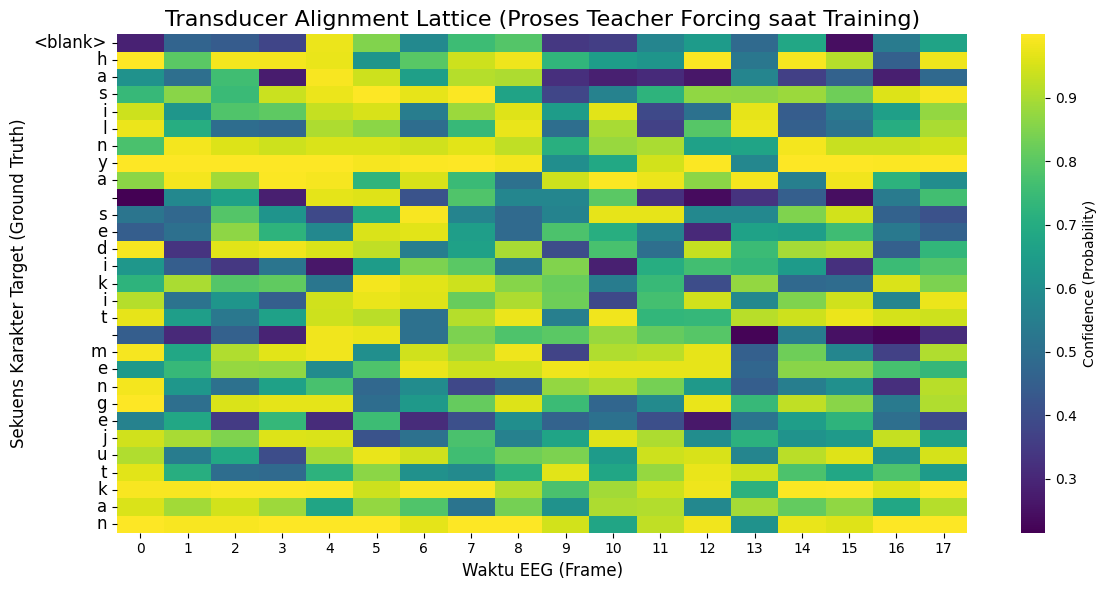

In [41]:
def live_greedy_decode_demo(model, features, tokenizer, delay=0.1, max_sym_per_frame=15):
    """Mendemonstrasikan inferensi RNN-Transducer sejati secara live"""
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        # Inisialisasi
        decoder_input = torch.tensor([[0]], dtype=torch.long, device=DEVICE)
        hidden_state = model.decoder.init_hidden(1, DEVICE)
        predicted_chars = []
        
        t = 0
        sym_count = 0 # Penghitung huruf berturut-turut di frame yang sama
        
        print("Memulai proses decoding RNN-T (Sesuai cara kerja asli)...\n")
        print("-" * 50)
        
        # Loop berhenti jika sudah mencapai frame EEG terakhir
        while t < encoder_out.size(1):
            current_enc_frame = encoder_out[:, t:t+1, :]
            decoder_out, next_hidden_state = model.decoder(decoder_input, hidden_state)
            
            enc_proj = model.joiner.encoder_proj(current_enc_frame)
            dec_proj = model.joiner.decoder_proj(decoder_out)
            joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
            joint = model.joiner.activation(joint)
            logits = model.joiner.output_proj(joint)
            
            prob = torch.nn.functional.softmax(logits, dim=-1)
            predicted_idx = prob.argmax(dim=-1).item()
            
            # KEPUTUSAN RNN-TRANSDUCER SEJATI
            if predicted_idx != 0 and sym_count < max_sym_per_frame:
                # 1. Tebak huruf (Bukan Blank)
                char = tokenizer.int_to_text([predicted_idx])[0]
                predicted_chars.append(char)
                
                # 2. Update ingatan dekoder
                decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long, device=DEVICE)
                hidden_state = next_hidden_state
                
                # 3. TETAP DI FRAME YANG SAMA (t tidak ditambah)
                sym_count += 1
            else:
                # Jika Blank diprediksi: MAJU KE FRAME BERIKUTNYA
                t += 1
                sym_count = 0 # Reset penghitung huruf
            
            current_sentence = "".join(predicted_chars)
            print(f"\r[Frame {t:03d}/{encoder_out.size(1)}] Prediksi: {current_sentence}", end="")
            time.sleep(delay)
            
        print("\n" + "-" * 50)
        print(f"Hasil Akhir  : {''.join(predicted_chars)}")
        print(f"Ground Truth : {ground_truth_sentence}")

live_greedy_decode_demo(model, features, tokenizer, delay=0.05)

def inspect_top_k_candidates(model, features, tokenizer, top_k=3, inspect_steps=10):
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        decoder_input = torch.tensor([[0]], dtype=torch.long, device=DEVICE)
        hidden_state = model.decoder.init_hidden(1, DEVICE)
        
        print(f"Mengintip {top_k} tebakan teratas secara Autoregressive (Sesuai Inferensi Asli):")
        print("="*80)
        
        t = 0
        sym_count = 0
        step = 1
        
        while t < encoder_out.size(1) and step <= inspect_steps:
            current_enc_frame = encoder_out[:, t:t+1, :]
            decoder_out, next_hidden_state = model.decoder(decoder_input, hidden_state)
            
            enc_proj = model.joiner.encoder_proj(current_enc_frame)
            dec_proj = model.joiner.decoder_proj(decoder_out)
            joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
            joint = model.joiner.activation(joint)
            logits = model.joiner.output_proj(joint)
            
            probs = torch.nn.functional.softmax(logits, dim=-1)[0, 0, 0, :]
            top_probs, top_indices = torch.topk(probs, top_k)
            
            print(f"Step {step:02d} (T={t:03d}) |", end=" ")
            for i in range(top_k):
                char_idx = top_indices[i].item()
                char_val = tokenizer.int_to_text([char_idx])[0] if char_idx != 0 else '<blank>'
                prob_val = top_probs[i].item() * 100
                print(f"#{i+1}: '{char_val}' ({prob_val:.1f}%)", end="  |  ")
            
            # Eksekusi rute teratas untuk update state selanjutnya
            predicted_idx = top_indices[0].item()
            print(f" --> Terpilih: '{tokenizer.int_to_text([predicted_idx])[0] if predicted_idx != 0 else '<blank>'}'")
            
            if predicted_idx != 0 and sym_count < 15:
                decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long, device=DEVICE)
                hidden_state = next_hidden_state
                sym_count += 1
            else:
                t += 1
                sym_count = 0
                
            step += 1

inspect_top_k_candidates(model, features, tokenizer, top_k=3, inspect_steps=50)

def plot_joiner_training_alignment(model, features, targets, tokenizer):
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        # Teacher Forcing (Khas Proses Training)
        batch_size = targets.shape[0]
        blank_col = torch.zeros((batch_size, 1), dtype=torch.long, device=DEVICE)
        decoder_input = torch.cat([blank_col, targets], dim=1)
        hidden_state = model.decoder.init_hidden(batch_size, DEVICE)
        
        decoder_out, _ = model.decoder(decoder_input, hidden_state)
        
        enc_proj = model.joiner.encoder_proj(encoder_out)
        dec_proj = model.joiner.decoder_proj(decoder_out)
        joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
        joint = model.joiner.activation(joint)
        logits = model.joiner.output_proj(joint)
        
        probs = torch.nn.functional.softmax(logits, dim=-1)
        max_probs = probs.max(dim=-1).values[0].cpu().numpy()
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(max_probs.T, cmap='viridis', cbar_kws={'label': 'Confidence (Probability)'})
        
        target_chars = ['<blank>'] + [tokenizer.int_to_text([i.item()])[0] for i in targets[0]]
        plt.yticks(ticks=np.arange(len(target_chars)) + 0.5, labels=target_chars, rotation=0, fontsize=12)
        
        plt.title("Transducer Alignment Lattice (Proses Teacher Forcing saat Training)", fontsize=16)
        plt.xlabel("Waktu EEG (Frame)", fontsize=12)
        plt.ylabel("Sekuens Karakter Target (Ground Truth)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

plot_joiner_training_alignment(model, features, targets, tokenizer)